In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [30]:
def encode_boxes(anchors, gt_boxes):
    tx = (gt_boxes[:, 0] - anchors[:, 0]) / anchors[:, 2]
    ty = (gt_boxes[:, 1] - anchors[:, 1]) / anchors[:, 3]
    tw = torch.log(gt_boxes[:, 2] / anchors[:, 2])
    th = torch.log(gt_boxes[:, 3] / anchors[:, 3])
    return torch.stack([tx, ty, tw, th], dim=1)

def decode_boxes(anchors, offsets):
    x = offsets[:, 0] * anchors[:, 2] + anchors[:, 0]
    y = offsets[:, 1] * anchors[:, 3] + anchors[:, 1]
    w = torch.exp(offsets[:, 2]) * anchors[:, 2]
    h = torch.exp(offsets[:, 3]) * anchors[:, 3]
    return torch.stack([x, y, w, h], dim=1)

def generate_anchors(feature_size, image_size, scales, ratios):
    fh, fw = feature_size
    ih, iw = image_size

    shift_y = torch.arange(0, fh) * (ih / fh) + (ih / fh) / 2
    shift_x = torch.arange(0, fw) * (iw / fw) + (iw / fw) / 2
    shift_yy, shift_xx = torch.meshgrid(shift_y, shift_x, indexing='ij')

    anchors = []

    for scale in scales:
        for ratio in ratios:
            area = scale * scale
            w = torch.sqrt(torch.tensor(area / ratio))
            h = w * ratio

            for y in range(fh):
                for x in range(fw):
                    cx = shift_xx[y, x]
                    cy = shift_yy[y, x]
                    anchors.append([cx, cy, w, h])

    return torch.tensor(anchors, dtype=torch.float32)

def test_bbox_encoding():
    anchors = torch.tensor([
        [100, 100, 50, 50],
        [200, 150, 60, 40],
        [150, 200, 40, 80]
    ], dtype=torch.float32)

    gt_boxes = torch.tensor([
        [105, 102, 55, 48],
        [195, 155, 65, 45],
        [148, 205, 42, 85]
    ], dtype=torch.float32)

    encoded = encode_boxes(anchors, gt_boxes)
    print(encoded)

    decoded = decode_boxes(anchors, encoded)
    print(decoded)
    print(gt_boxes)

    error = torch.abs(decoded - gt_boxes).mean()
    print(error)

    anchors_generated = generate_anchors(
        feature_size=(8, 8),
        image_size=(256, 256),
        scales=[32, 64, 128],
        ratios=[0.5, 1.0, 2.0]
    )
    print(len(anchors_generated))
    print(anchors_generated[:5])

test_bbox_encoding()

tensor([[ 0.1000,  0.0400,  0.0953, -0.0408],
        [-0.0833,  0.1250,  0.0800,  0.1178],
        [-0.0500,  0.0625,  0.0488,  0.0606]])
tensor([[105., 102.,  55.,  48.],
        [195., 155.,  65.,  45.],
        [148., 205.,  42.,  85.]])
tensor([[105., 102.,  55.,  48.],
        [195., 155.,  65.,  45.],
        [148., 205.,  42.,  85.]])
tensor(0.)
576
tensor([[ 16.0000,  16.0000,  45.2548,  22.6274],
        [ 48.0000,  16.0000,  45.2548,  22.6274],
        [ 80.0000,  16.0000,  45.2548,  22.6274],
        [112.0000,  16.0000,  45.2548,  22.6274],
        [144.0000,  16.0000,  45.2548,  22.6274]])


In [31]:
class YOLOLayer(nn.Module):
    def __init__(self, anchors, num_classes, img_size):
        super(YOLOLayer, self).__init__()
        self.anchors = anchors
        self.num_anchors = len(anchors)
        self.num_classes = num_classes
        self.img_size = img_size
        self.grid_size = 0
        self.grid_x = None
        self.grid_y = None
        self.anchor_w = None
        self.anchor_h = None

    def create_grid(self, grid_size, device):
        self.grid_size = grid_size
        g = grid_size

        self.grid_x = torch.arange(g, device=device, dtype=torch.float).repeat(g, 1).view([1, 1, g, g])
        self.grid_y = torch.arange(g, device=device, dtype=torch.float).repeat(g, 1).t().view([1, 1, g, g])

        self.anchor_w = torch.tensor([anchor[0] for anchor in self.anchors], device=device).view((1, self.num_anchors, 1, 1))
        self.anchor_h = torch.tensor([anchor[1] for anchor in self.anchors], device=device).view((1, self.num_anchors, 1, 1))

        self.anchor_w = self.anchor_w / self.img_size * grid_size
        self.anchor_h = self.anchor_h / self.img_size * grid_size

    def forward(self, x):
        batch_size, _, grid_size, _ = x.size()
        device = x.device

        prediction = x.view(batch_size, self.num_anchors, self.num_classes + 5, grid_size, grid_size)
        prediction = prediction.permute(0, 1, 3, 4, 2).contiguous()

        tx = torch.sigmoid(prediction[..., 0])
        ty = torch.sigmoid(prediction[..., 1])
        tw = prediction[..., 2]
        th = prediction[..., 3]
        conf = torch.sigmoid(prediction[..., 4])
        pred_cls = torch.sigmoid(prediction[..., 5:])

        if grid_size != self.grid_size:
            self.create_grid(grid_size, device)

        pred_x = (tx + self.grid_x) / grid_size
        pred_y = (ty + self.grid_y) / grid_size
        pred_w = torch.exp(tw) * self.anchor_w / grid_size
        pred_h = torch.exp(th) * self.anchor_h / grid_size

        pred_boxes = torch.stack([pred_x, pred_y, pred_w, pred_h], dim=-1)

        output = torch.cat(
            (pred_boxes.view(batch_size, -1, 4),
             conf.view(batch_size, -1, 1),
             pred_cls.view(batch_size, -1, self.num_classes)),
            -1
        )

        return output

class SimpleYOLO(nn.Module):
    def __init__(self, num_classes=80):
        super(SimpleYOLO, self).__init__()
        self.num_classes = num_classes

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.output_conv = nn.Conv2d(256, 3 * (5 + num_classes), 1)

        anchors = [(10, 13), (16, 30), (33, 23)]
        self.yolo_layer = YOLOLayer(anchors, num_classes, img_size=416)

    def forward(self, x):
        features = self.backbone(x)
        output = self.output_conv(features)
        return self.yolo_layer(output)

def test_yolo():
    model = SimpleYOLO(num_classes=10).to(device)
    x = torch.randn(2, 3, 416, 416).to(device)

    with torch.no_grad():
        output = model(x)
        print(output.shape)
        print(output.shape[0])
        print(output.shape[1])
        print(output.shape[2])

test_yolo()

torch.Size([2, 2028, 15])
2
2028
15


In [32]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [33]:
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

In [34]:
class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

In [35]:
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [36]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear = True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        # 인코더
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        # 디코더
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        # self.up4 = Up(128, 64 // factor, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        # 인코더 (스킵 커넥션 사용)
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # 디코더 (스킵 커넥션 사용)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)

        return logits

torch.Size([2, 3, 256, 256])
torch.Size([2, 1, 256, 256])
0.5035020112991333


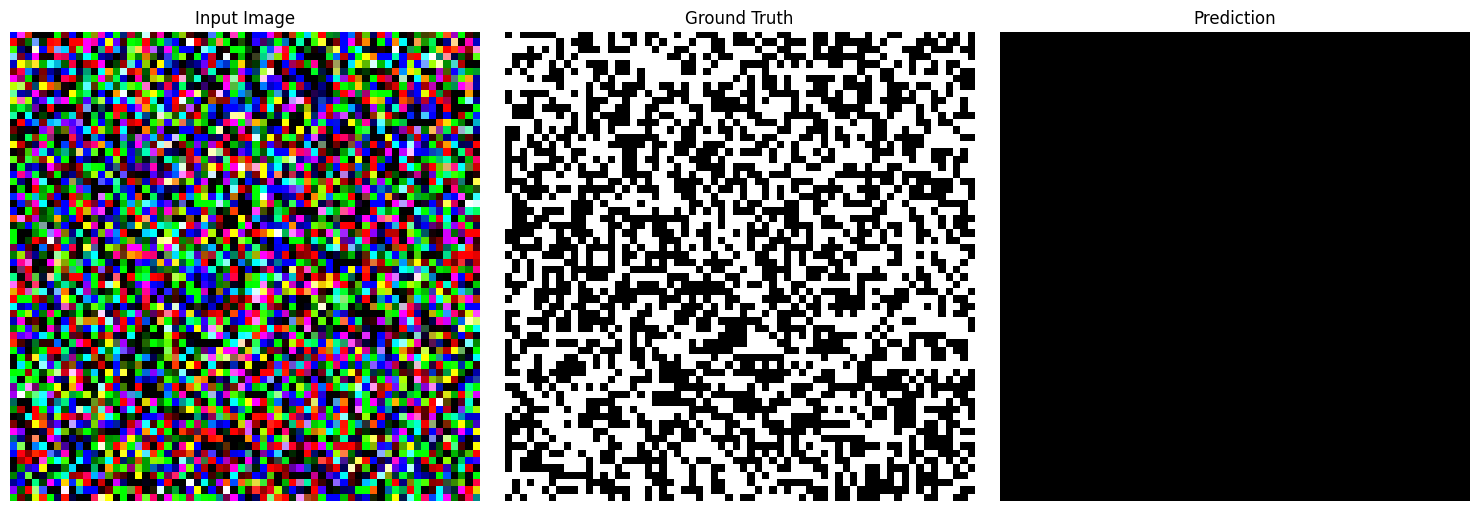

In [37]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        union = probs.sum() + targets.sum()
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)

        return 1.0 - dice

def visualize_predictions(model, image, mask, device='cpu'):
    model.eval()

    if image.dim() == 3:
        image_tensor = image.unsqueeze(0).to(device)
    else:
        image_tensor = image.to(device)

    with torch.no_grad():
        output = model(image_tensor)
        pred = torch.sigmoid(output) > 0.5

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    if image.dim() == 4:
        img_show = image[0].permute(1, 2, 0).cpu().numpy()
    else:
        img_show = image.permute(1, 2, 0).cpu().numpy()
    img_show = np.clip(img_show, 0, 1)
    axes[0].imshow(img_show)
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    if mask.dim() == 4:
        mask_show = mask[0].squeeze().cpu().numpy()
    else:
        mask_show = mask.squeeze().cpu().numpy()
    axes[1].imshow(mask_show, cmap='gray')
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    pred_show = pred[0].squeeze().cpu().numpy()
    axes[2].imshow(pred_show, cmap='gray')
    axes[2].set_title('Prediction')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

def test_unet():
    model = UNet(n_channels=3, n_classes=1).to(device)

    batch_size = 2
    x = torch.randn(batch_size, 3, 256, 256).to(device)

    with torch.no_grad():
        output = model(x)
        print(x.shape)
        print(output.shape)

    target = torch.randint(0, 2, (batch_size, 1, 256, 256)).float().to(device)
    dice_loss = DiceLoss()
    loss = dice_loss(output, target)
    print(loss.item())

    model_cpu = UNet(n_channels=3, n_classes=1)
    test_image = torch.randn(3, 64, 64)
    test_mask = torch.randint(0, 2, (1, 64, 64)).float()

    visualize_predictions(model_cpu, test_image, test_mask, device='cpu')

test_unet()

In [38]:
import torch.nn.functional as F

def test_time_augmentation(model, image, device='cpu', num_augmentations=5):
    model.eval()
    predictions = []

    with torch.no_grad():
        if image.dim() == 3:
            input_tensor = image.unsqueeze(0).to(device)
        else:
            input_tensor = image.to(device)
        original_pred = model(input_tensor)
        predictions.append(original_pred)

    augmentations = [
        lambda x: torch.flip(x, dims=[-1]),
        lambda x: torch.flip(x, dims=[-2]),
        lambda x: torch.rot90(x, 1, dims=[-2, -1]),
        lambda x: torch.rot90(x, 2, dims=[-2, -1]),
        lambda x: torch.rot90(x, 3, dims=[-2, -1]),
    ]

    reverse_augmentations = [
        lambda x: torch.flip(x, dims=[-1]),
        lambda x: torch.flip(x, dims=[-2]),
        lambda x: torch.rot90(x, -1, dims=[-2, -1]),
        lambda x: torch.rot90(x, -2, dims=[-2, -1]),
        lambda x: torch.rot90(x, -3, dims=[-2, -1]),
    ]

    for i, (aug_fn, reverse_fn) in enumerate(zip(augmentations[:num_augmentations-1],
                                                reverse_augmentations[:num_augmentations-1])):
        with torch.no_grad():
            if image.dim() == 3:
                augmented = aug_fn(image).unsqueeze(0).to(device)
            else:
                augmented = aug_fn(image).to(device)

            pred = model(augmented)

            if pred.dim() == 4:
                pred_restored = reverse_fn(pred)
            else:
                pred_restored = pred

            predictions.append(pred_restored)

    final_pred = torch.mean(torch.stack(predictions), dim=0)
    return final_pred

In [39]:
def multiscale_tta(model, image, scales=[0.8, 1.0, 1.2], device='cpu'):
    model.eval()
    predictions = []
    original_size = image.shape[-2:]

    for scale in scales:
        new_size = [int(s * scale) for s in original_size]
        scaled_image = F.interpolate(
            image.unsqueeze(0),
            size=new_size,
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        pred = test_time_augmentation(model, scaled_image, device, num_augmentations=3)

        if pred.dim() == 4:
            pred_resized = F.interpolate(
                pred,
                size=original_size,
                mode='bilinear',
                align_corners=False
            )
        else:
            pred_resized = pred

        predictions.append(pred_resized)

    final_pred = torch.mean(torch.stack(predictions), dim=0)
    return final_pred

In [40]:
class ModelEnsemble(nn.Module):
    def __init__(self, models):
        super(ModelEnsemble, self).__init__()
        self.models = nn.ModuleList(models)

    def forward(self, x):
        predictions = []
        for model in self.models:
            pred = model(x)
            predictions.append(pred)

        ensemble_pred = torch.mean(torch.stack(predictions), dim=0)
        return ensemble_pred

In [41]:
def test_tta():
    class SimpleClassifier(nn.Module):
        def __init__(self, num_classes=10):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(32, num_classes)
            )

        def forward(self, x):
            return self.features(x)

    model = SimpleClassifier().to(device)
    test_image = torch.randn(3, 64, 64)

    with torch.no_grad():
        normal_pred = model(test_image.unsqueeze(0).to(device))
        print(normal_pred.shape)

    tta_pred = test_time_augmentation(model, test_image, device, num_augmentations=4)
    print(tta_pred.shape)

    ms_tta_pred = multiscale_tta(model, test_image, scales=[0.9, 1.0, 1.1], device=device)
    print(ms_tta_pred.shape)

    print(torch.max(torch.softmax(normal_pred, dim=1)).item())
    print(torch.max(torch.softmax(tta_pred, dim=1)).item())
    print(torch.max(torch.softmax(ms_tta_pred, dim=1)).item())

test_tta()

torch.Size([1, 10])
torch.Size([1, 10])
torch.Size([1, 10])
0.12372881919145584
0.12380554527044296
0.1199973002076149


In [42]:
class MultiTaskModel(nn.Module):
    def __init__(self, num_classes=10, num_seg_classes=1):
        super(MultiTaskModel, self).__init__()

        self.shared_encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

        self.segmentation = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(32, num_seg_classes, 1)
        )

    def forward(self, x):
        shared_features = self.shared_encoder(x)

        cls_output = self.classifier(shared_features)

        seg_output = self.segmentation(shared_features)

        return cls_output, seg_output

In [43]:
class MultiTaskLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5):
        super(MultiTaskLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.cls_loss = nn.CrossEntropyLoss()
        self.seg_loss = nn.BCEWithLogitsLoss()

    def forward(self, cls_pred, cls_target, seg_pred, seg_target):
        loss_cls = self.cls_loss(cls_pred, cls_target)

        loss_seg = self.seg_loss(seg_pred, seg_target)

        total_loss = self.alpha * loss_cls + self.beta * loss_seg

        return total_loss, loss_cls, loss_seg

In [44]:
class UncertaintyWeightedLoss(nn.Module):
    def __init__(self):
        super(UncertaintyWeightedLoss, self).__init__()
        self.log_sigma_cls = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_seg = nn.Parameter(torch.tensor(0.0))
        self.cls_loss = nn.CrossEntropyLoss()
        self.seg_loss = nn.BCEWithLogitsLoss()

    def forward(self, cls_pred, cls_target, seg_pred, seg_target):
        loss_cls = self.cls_loss(cls_pred, cls_target)

        loss_seg = self.seg_loss(seg_pred, seg_target)

        precision_cls = torch.exp(-self.log_sigma_cls)
        precision_seg = torch.exp(-self.log_sigma_seg)

        weighted_loss_cls = precision_cls * loss_cls + self.log_sigma_cls
        weighted_loss_seg = precision_seg * loss_seg + self.log_sigma_seg

        total_loss = weighted_loss_cls + weighted_loss_seg

        return total_loss, loss_cls, loss_seg

In [45]:
def train_multitask_model(model, train_loader, criterion, optimizer, device, epochs=5):
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        running_cls_loss = 0.0
        running_seg_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, cls_targets, seg_targets) in enumerate(train_loader):
            images = images.to(device)
            cls_targets = cls_targets.to(device)
            seg_targets = seg_targets.to(device)

            optimizer.zero_grad()

            cls_outputs, seg_outputs = model(images)

            total_loss, cls_loss, seg_loss = criterion(
                cls_outputs, cls_targets, seg_outputs, seg_targets
            )

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()
            running_cls_loss += cls_loss.item()
            running_seg_loss += seg_loss.item()

            _, predicted = cls_outputs.max(1)
            total += cls_targets.size(0)
            correct += predicted.eq(cls_targets).sum().item()

            if batch_idx % 50 == 0:
                print(batch_idx)
                print(total_loss.item())
                print(cls_loss.item())
                print(seg_loss.item())
                print(correct/total*100)

In [46]:
class MultiTaskDataset:
    def __init__(self, num_samples=1000, img_size=128):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image = torch.randn(3, self.img_size, self.img_size)

        cls_label = torch.randint(0, 10, (1,)).item()

        seg_mask = torch.randint(0, 2, (1, self.img_size, self.img_size)).float()

        return image, cls_label, seg_mask

In [54]:
def test_multitask():
    model = MultiTaskModel(num_classes=10,
                           num_seg_classes=1).to(device)
    batch_size = 4

    train_dataset = MultiTaskDataset(num_samples=1000,
                                     img_size=128)
    train_loader = torch.utils.data.DataLoader(train_dataset,
                                               batch_size=batch_size,
                                               shuffle=True)
    # cirterion = MultiTaskLoss()
    # optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = UncertaintyWeightedLoss().to(device)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(criterion.parameters()))
    images = torch.randn(batch_size,3,128,128).to(device)
    train_multitask_model(model,
                          train_loader,
                          criterion,
                          optimizer,
                          device,
                          epochs=5)
test_multitask()

0
3.2151618003845215
2.5065722465515137
0.7085895538330078
0.0
50
2.832186698913574
2.208698034286499
0.6933369040489197
11.76470588235294
100
2.909792184829712
2.360255718231201
0.6932101249694824
9.653465346534654
150
2.8371388912200928
2.343714714050293
0.6933214664459229
9.602649006622517
200
2.7487857341766357
2.2975895404815674
0.6931755542755127
9.328358208955224
0
2.7155728340148926
2.307419776916504
0.6931949853897095
25.0
50
2.7174594402313232
2.3558497428894043
0.6932637095451355
11.27450980392157
100
2.6707680225372314
2.3359928131103516
0.6932240724563599
9.405940594059405
150
2.6405529975891113
2.331240177154541
0.6932318806648254
8.609271523178808
200
2.5801069736480713
2.277280807495117
0.6932181119918823
7.835820895522389
0
2.5823585987091064
2.3081021308898926
0.693240761756897
25.0
50
2.5704116821289062
2.3152265548706055
0.6931706070899963
5.392156862745098
100
2.5577809810638428
2.317936897277832
0.6931679844856262
8.663366336633663
150
2.5373778343200684
2.3048679